In [1]:
# imports
import pandas as pd
import tensorflow as tf
# utilities
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from utils.processing import filter_rsos_by_min_state_count, rso_train_test_split, assemble_scaled_state_df

2025-05-06 16:58:24.933563: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-06 16:58:24.933600: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-06 16:58:24.934381: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-06 16:58:24.939845: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Separate features into different categories
X_numerical = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER'] 
X_numerical_revised = X_numerical + ['MEAN_MOTION_2ND_DER', 'B_STAR']
X_features_to_use = X_numerical_revised
response = 'TYPE'

df_final = pd.read_csv('../data/large/final_df_v1.csv') # <-- Run Part 1 of DataConsolidation.ipynb to produce file
df_final = df_final.sort_values(by=['NUMBER', 'EPOCH'])
df_final.reset_index(inplace=True, drop=True)

### Step 1: Scale, reshape data, and pad

In [3]:
# Scale state data
scaler = StandardScaler()
df_scaled = df_final.copy()
df_scaled[X_features_to_use] = scaler.fit_transform(df_final[X_features_to_use])

In [4]:
# Get maximum number of states for all objects
MAX_STATE_COUNT = df_scaled['NUMBER'].value_counts().max()
N_FEATURES = len(X_features_to_use)

# Group by objects
grouped = df_scaled.groupby('NUMBER')

X_padded = []
y_labels = []

# Iterate through objects and pad
for number, group in grouped:

    # Pad states
    states = group[X_features_to_use].values.astype(np.float32)
    padded = tf.keras.preprocessing.sequence.pad_sequences(
        [states], maxlen=MAX_STATE_COUNT, dtype='float32',
        padding='post', truncating='post', value=-999.0 # <-- -999.0 never appears in our data, safe to use as the padding token
    )
    X_padded.append(padded[0])

    # Assign label
    label = group[response].iloc[0]
    y_labels.append(label)

X_array = np.array(X_padded).astype(np.float32)
y_array = np.array(y_labels)

print(f'X shape: {X_array.shape}')
print(f'y shape: {y_array.shape}')

X shape: (30495, 49, 11)
y shape: (30495,)


In [5]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_array).astype(np.int32)

### Step 2: Split to train/test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_array, y_encoded, test_size=0.2, random_state=209, stratify=y_encoded)

In [7]:
# Repeat for the state model
y_train_repeated = np.repeat(np.expand_dims(y_train, axis=-1), MAX_STATE_COUNT, axis=-1).astype(np.int32)

In [8]:
# Training parameters
EPOCHS = 50
BATCH_SIZE = 32
LR = 0.0005

# Define state model
state_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_FEATURES,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(3, activation='softmax'),
])

# Input is a tensor of shape (BATCH_SIZE, MAX_STATE_COUNT, N_FEATURES
input = tf.keras.layers.Input(shape=(MAX_STATE_COUNT, N_FEATURES))

# Values of -999.0 are ignored
x = tf.keras.layers.Masking(mask_value=-999.0)(input)

# Pass each state independently into the state_model, save output as 'state_output'
state_output = tf.keras.layers.TimeDistributed(state_model, name='state_output')(x)

# LSTM with 128 units
# x = tf.keras.layers.LSTM(128)(state_output)

# Multihead Attention
# x = tf.keras.layers.MultiHeadAttention(
#     num_heads=8,
#     key_dim=128,
#     dropout=0.,
# )(query=state_output, value=state_output)
# x = tf.keras.layers.GlobalAveragePooling1D()(x)

# Feedforward neural network as the object_model
x = tf.keras.layers.Flatten()(state_output)
x = tf.keras.layers.Dense(512)(x)
x = tf.keras.layers.Dropout(0.15)(x)
x = tf.keras.layers.Dense(256)(x)
x = tf.keras.layers.Dropout(0.15)(x)
x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.Dropout(0.15)(x)
x = tf.keras.layers.Dense(64)(x)
x = tf.keras.layers.Dropout(0.15)(x)

# Save the output of the object model as 'object_output'
object_output = tf.keras.layers.Dense(3, activation='softmax', name='object_output')(x)

object_model = tf.keras.Model(inputs=input, outputs=[state_output, object_output], name='object_model')
object_model.summary()

object_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR), 
    loss={'state_output': 'sparse_categorical_crossentropy', 'object_output': 'sparse_categorical_crossentropy'}, 
    loss_weights={'state_output': 1, 'object_output': 3}, # More emphasis on getting final object prediction right
    weighted_metrics={'state_output': 'accuracy', 'object_output': 'accuracy'},
)

# Create mask for the loss function so padded values don't contribute to the loss
mask = (X_train != -999.0).any(axis=-1)
state_sample_weights = mask.astype(np.float32)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_object_output_loss', patience=10, verbose=1)

model_history = object_model.fit(
    X_train,
    {'state_output': y_train_repeated, 'object_output': y_train},
    sample_weight={'state_output':state_sample_weights, 'object_output': np.ones(len(y_train))},
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)
history = model_history.history

2025-05-06 16:58:52.074504: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:38:00.0, compute capability: 8.9


Model: "object_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 49, 11)]          0         
                                                                 
 masking (Masking)           (None, 49, 11)            0         
                                                                 
 state_output (TimeDistribu  (None, 49, 3)             170755    
 ted)                                                            
                                                                 
 flatten (Flatten)           (None, 147)               0         
                                                                 
 dense_4 (Dense)             (None, 512)               75776     
                                                                 
 dropout_3 (Dropout)         (None, 512)               0         
                                                      

2025-05-06 16:58:55.166465: I external/local_xla/xla/service/service.cc:168] XLA service 0x14e85c2d6bc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-06 16:58:55.166509: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2025-05-06 16:58:55.171608: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-06 16:58:55.190325: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
I0000 00:00:1746565135.255489   26089 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


610/610 [==============================] - 7s 5ms/step - loss: 2.2664 - state_output_loss: 0.7247 - object_output_loss: 0.5139 - state_output_accuracy: 0.7481 - object_output_accuracy: 0.8050 - val_loss: 1.7634 - val_state_output_loss: 0.6358 - val_object_output_loss: 0.3759 - val_state_output_accuracy: 0.8144 - val_object_output_accuracy: 0.8658
Epoch 2/50
610/610 [==============================] - 3s 4ms/step - loss: 1.7656 - state_output_loss: 0.5992 - object_output_loss: 0.3888 - state_output_accuracy: 0.8117 - object_output_accuracy: 0.8664 - val_loss: 1.5408 - val_state_output_loss: 0.5427 - val_object_output_loss: 0.3327 - val_state_output_accuracy: 0.8285 - val_object_output_accuracy: 0.8795
Epoch 3/50
610/610 [==============================] - 3s 4ms/step - loss: 1.6533 - state_output_loss: 0.5668 - object_output_loss: 0.3622 - state_output_accuracy: 0.8225 - object_output_accuracy: 0.8753 - val_loss: 1.4754 - val_state_output_loss: 0.5345 - val_object_output_loss: 0.3136 - va

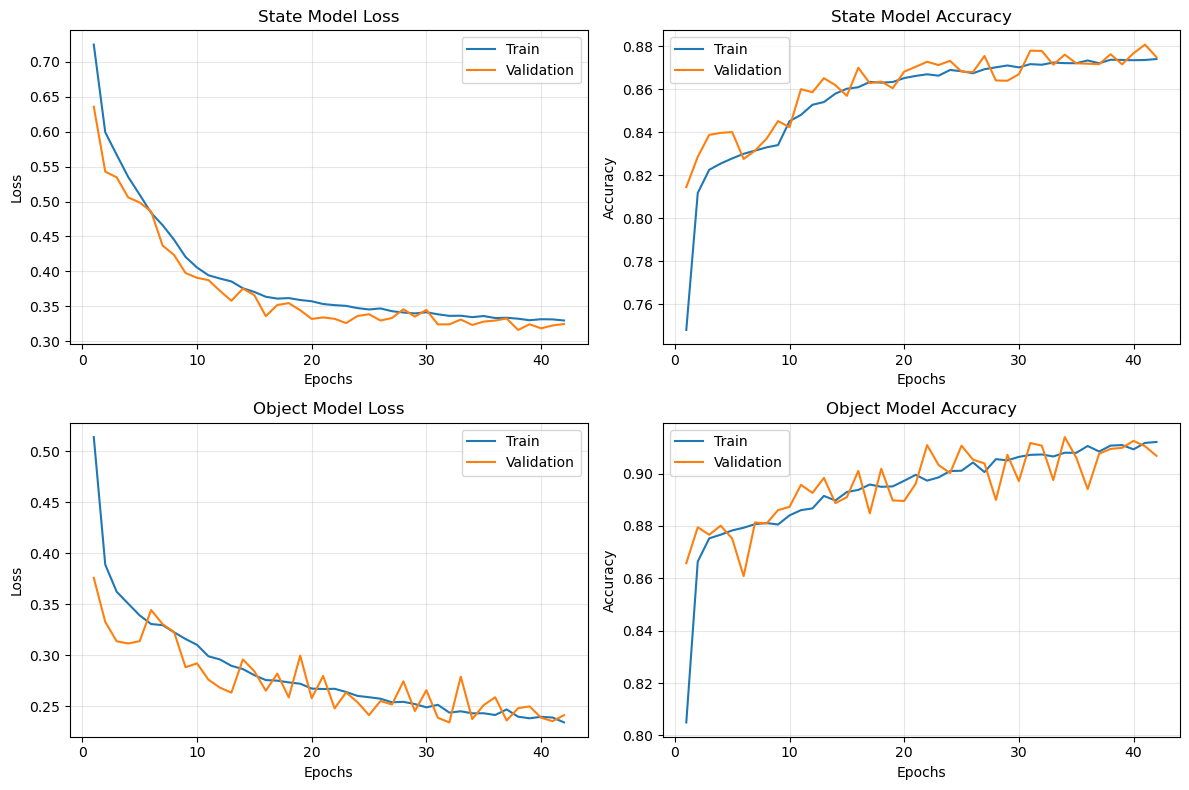

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
for i, level in enumerate(['state', 'object']):
    for j, metric in enumerate(['loss', 'accuracy']):
        for k, split in enumerate(['', 'val_']):
            data = history[f'{split}{level}_output_{metric}']
            axes[i][j].plot(np.arange(len(data))+1, data, color=f'C{k}', label='Train' if split == '' else 'Validation')
            axes[i][j].legend()
            axes[i][j].set_xlabel('Epochs')
            axes[i][j].set_ylabel(metric.title())
            axes[i][j].set_title(f'{level.title()} Model {metric.title()}')
            axes[i][j].grid(alpha=0.3)

plt.tight_layout()